# Lecture 18: Exam review and `odeint`
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PIMILab/ENGR1050/blob/main/notebooks/lec18.ipynb)


## Overview

We'll do one last example today practicing using the `ODE_solver` class, as well as stepping through how to equivalently do the same thing with Scipy's `odeint` function. For this course, we wrote our own method so that we could continue to get some hands on experience designing and using classes. In practice though, Explicit Euler isn't a great method. It takes lots of steps to give reasonable accuracy and will "blow up" if there isn't enough resolution.

We'll do one last exercise fitting a model to data from the early days of the COVID pandemic. In the same way that we fit our proportional control model to the helicopter, we can choose constants to fit other sorts of data. The tools that you've picked up are *general*! Whether you go on to build helicopters or model financial markets, you now have the skill set to build models of systems and use those models to make predictions.

## ODE of the week: The SIR model for epidemiology

During the Covid days, *compartment models* were some of the first tools folks used in public policy to identify whether Covid would explode into a pandemic. You may remember from around those days that people were talking about $R_0$ ("R naught") and whether the curve could be flattened enough to prevent things from getting out of hand.

Compartment models are a broad class of ODEs that are used to model interactions between populations. In engineering, we use these to model chemical reactions, in bioengineering, these are used to model interactions between different types of cells, in environmental engineering, they are used to model population dynamics of different animals.

The SIR model is a simple compartment model used to predict the spread of a disease. It is a nice dynamical system because it is easy to understand the steady state behavior - there are two knobs on it that fix how fast the disease spreads compared to how fast the population can be made immune, and their relative magnitude tells you whether the disease will spread through the entire population.


# Be careful

- This is a scientific computing class, not an epidemiology class
- We are using this as an opportunity to see how the tools we've learned map onto different fields from something we all experienced
- Be careful of the conclusions you draw - this is a vastly oversimplified model and we are skipping many important aspects of the problem that epidemiologists needed to take into account

### The SIR model — compartments and equations

The SIR model splits the population into three compartments:
- S: susceptible (can catch the disease)
- I: infectious (can transmit the disease)
- R: removed (recovered or immune)

For a population with $N$ people, the SIR model is:


\begin{aligned}
\dot S &= -\beta \frac{S I}{N},\\
\dot I &= \beta \frac{S I}{N} - \gamma I,\\
\dot R &= \gamma I
\end{aligned}


where $\beta$ is the transmission rate and $\gamma$ is the recovery rate ($\frac{1}{\gamma}$ ≈ mean infectious period).

**Basic reproduction number**
- R0 = β / γ.
- If R0 > 1 a small introduction tends to grow into an epidemic; if R0 < 1 it dies out.

### Today's exercise

To prepare for the exam and also close out our unit, we will do one more pass using the ODE solver class to solve this system, and then we'll repeat using Scipy's more sophisticated solvers. In the block below I've pulled data out for the first couple months of the COVID outbreak in New York City.

This data is interesting because for the first couple weeks there were no social distancing protocols in place and there was unchecked exponential growth. A couple weeks in, social distancing protocols were put into place. We are going to try to calibrate those first couple weeks to an SIR model. This gives the flavor of how epidemiologists attempted to estimate how infectious COVID was in early days of the outbreak.

**From the news:** In the early days of COVID, a value of $R_0 = 4-5$ was reported in NYC, even though much lower values of $R_0 = 2-2.5$ were initially estimated by the World Health Organization. This caught many off-guard and led to many deaths.

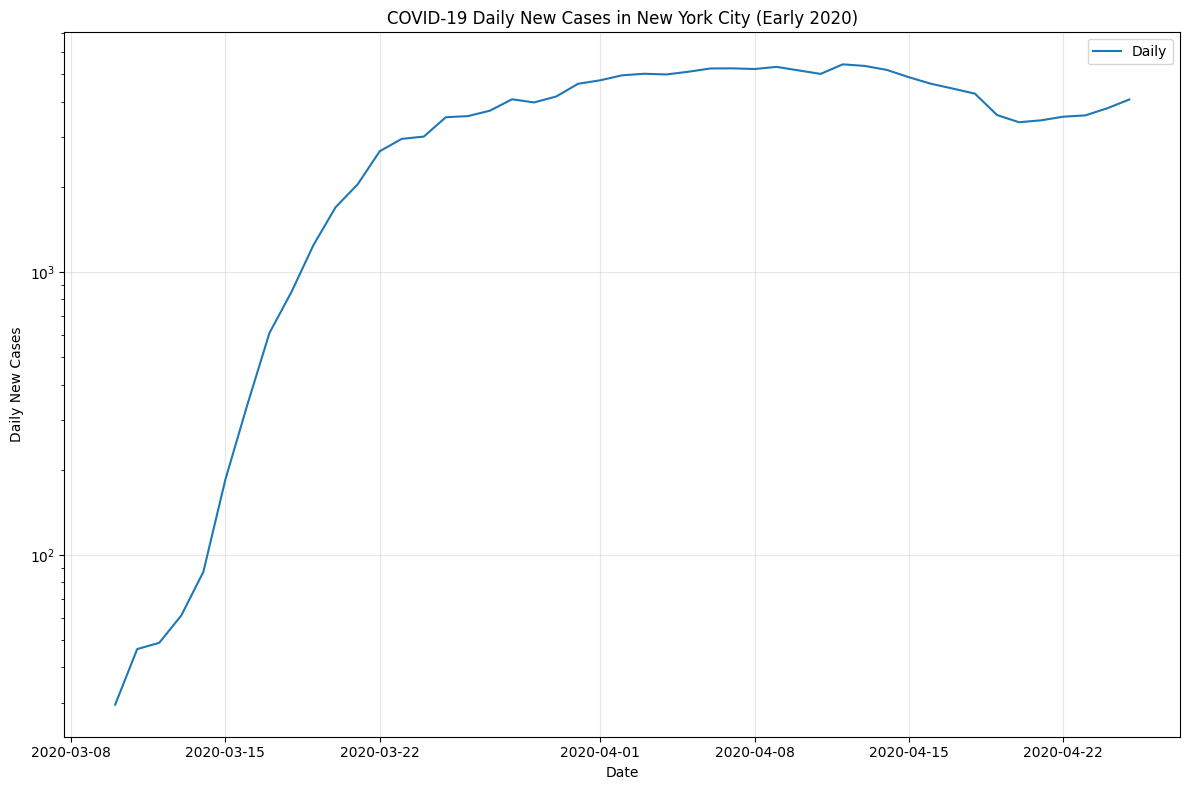

In [2]:
# Get New York COVID-19 data from NY Times
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

NYC_POP = 8336817
START, END = "2020-03-10", "2020-04-25"   # exponential growth through early NPI period

def load_nyc_cases(start=START, end=END, smooth=7):
    url = "https://raw.githubusercontent.com/nytimes/covid-19-data/master/us-counties.csv"
    df = pd.read_csv(url, parse_dates=["date"])
    df = df[(df.state=="New York") & (df.county=="New York City")].sort_values("date")
    df = df[(df.date>=pd.to_datetime(start)) & (df.date<=pd.to_datetime(end))].copy()
    df["new_cases"] = df["cases"].diff().clip(lower=0).fillna(0)
    if smooth and smooth>1:
        df["new_cases"] = df["new_cases"].rolling(smooth, center=True, min_periods=1).mean()
    df["t"] = (df.date - df.date.iloc[0]).dt.days.astype(float)
    return df.reset_index(drop=True)

early_period = load_nyc_cases()

# Plot the epidemic curve
plt.figure(figsize=(12, 8))
plt.semilogy(early_period['date'], early_period['new_cases'], label='Daily')
plt.title('COVID-19 Daily New Cases in New York City (Early 2020)')
plt.xlabel('Date')
plt.ylabel('Daily New Cases')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Solving with ODE solver class

As usual, here is our base class for solving an ODE:

In [3]:
import numpy as np

class ODE_solver:
    def __init__(self, t0, tf, y0, N):
        self.y0 = y0  # initial condition as numpy array
        self.t0 = t0  # initial time as float
        self.tf = tf  # final time as float
        self.N = N    # number of steps as integer
        self.h = (tf - t0) / float(N) # timestep size

        # We need to check what size y0 is and store that information
        self.dim = len(y0) #assumes that y0 is a list or array

        # Create a place to store the solution
        self.t_values = np.array([t0 + i*self.h for i in range(N+1)])  # time values
        self.solution = np.zeros((N+1, self.dim))  # solution array
        self.solution[0, :] = y0  # set initial condition

    def f(self,t,y):
        # Define the right-hand side of the ODE here, assuming a scalar t and a numpy array y
        # Example: dy/dt = -2y (for scalar y),
        # this function should return a numpy array of the same shape as y
        f = np.zeros_like(y)
        f[0] = -2 * y[0]  # Example for the first component
        return f

    def solve(self):
        # Implement explicit euler: y_n+1 = y_n + h*f(t_n, y_n)
        for n in range(self.N):
            t_n = self.t_values[n]
            y_n = self.solution[n, :]
            f_n = self.f(t_n, y_n)
            self.solution[n+1, :] = y_n + self.h * f_n
        return self.solution

**Your turn:** Build a child class to implement the SIR ODE

In [4]:
class SIR_solver(ODE_solver):
    """
    SIR model solver inheriting from ODE_solver.
    y = [S, I, R], N_pop is the total population (float).
    Parameters:
      t0, tf, y0, N  - forwarded to ODE_solver
      beta, gamma    - transmission and recovery rates
      N_pop          - total population
    """
    def __init__(self, t0, tf, y0, N, beta, gamma, N_pop):
        super().__init__(t0, tf, y0, N)
        self.beta = float(beta)
        self.gamma = float(gamma)
        self.N_pop = float(N_pop)

    def f(self, t, y):
        S = y[0]
        I = y[1]
        R = y[2]

        dSdt = -self.beta * S * I / self.N_pop
        dIdt = self.beta * S * I / self.N_pop - self.gamma * I
        dRdt = self.gamma * I
        return np.array([dSdt, dIdt, dRdt])

    def R0(self):
        return self.beta / self.gamma

### Experiment!

Modify the code below to play with the initial number of cases `initial_infected` and a range of `beta` values to match the first week or so of data. I set it up to match the initial WHO estimates that give `R0` in the 2-2.5 range.

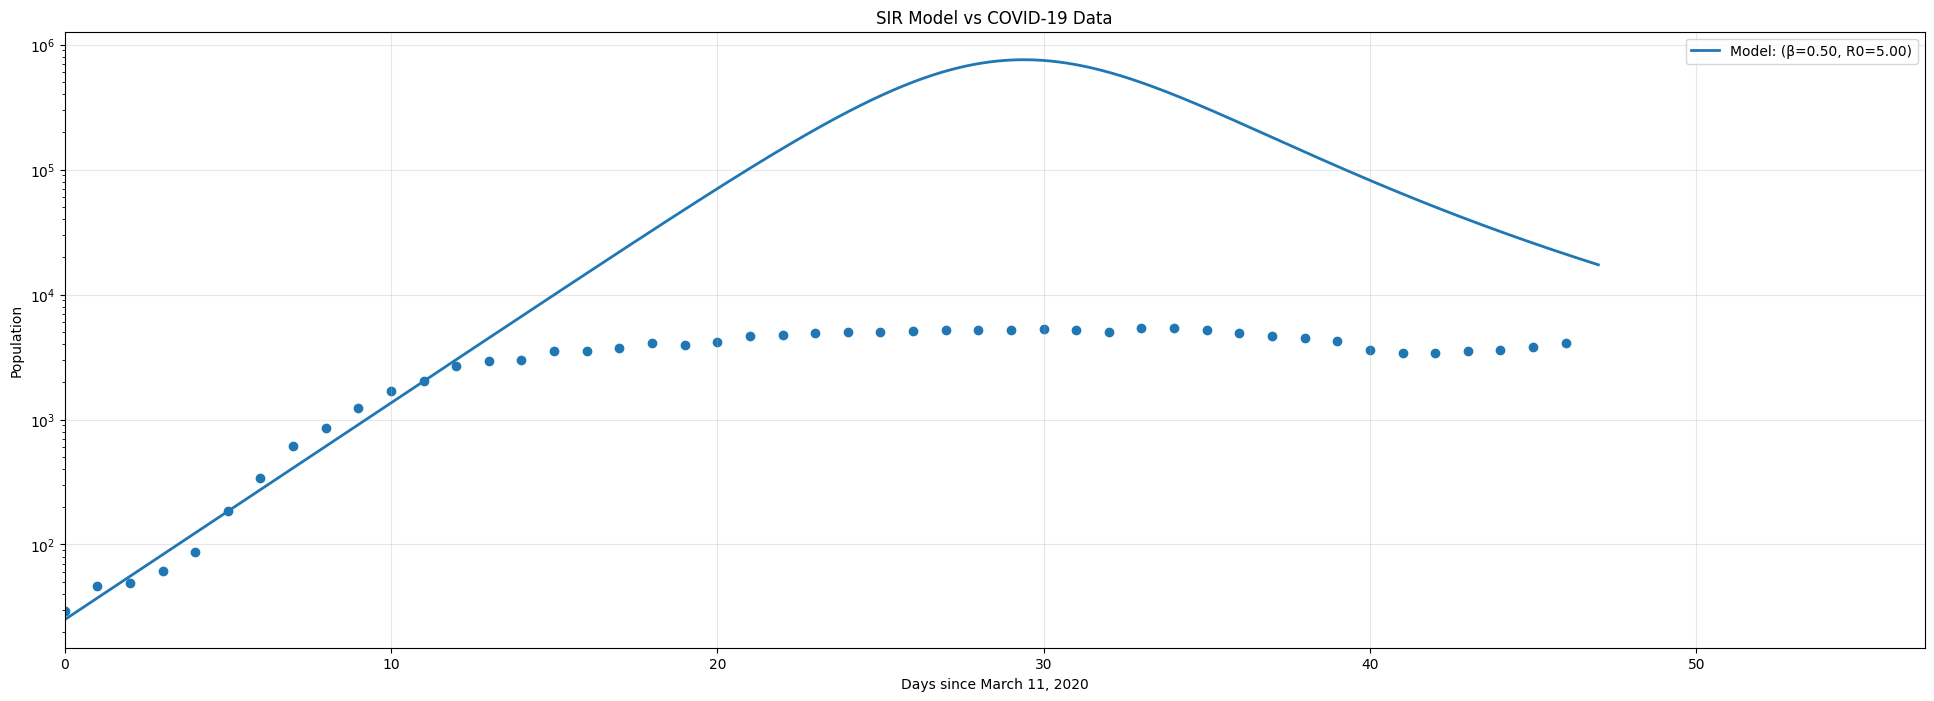

In [17]:
# Trim data to cut out days before cases were reported
cases = early_period['new_cases'].to_numpy()

# choose gamma for an average infectious period of 10 days
gamma = 1./10.
N_nyc = 8336817
# Time setup: match the data window
t0 = 0.0
tf = len(cases)
N_steps = 10000  # number of time steps for solver

# Initial conditions from the data. Offset the initial condition by 5 days to account for reporting lag
initial_infected = 50
y0 = np.array([N_nyc-initial_infected, initial_infected, 0])



# Generate solutions and plots for a range of beta values
plt.figure(figsize=(24, 8))
for beta in [0.5]:
    # Create and solve the SIR model
    sir_solver = SIR_solver(t0, tf, y0, N_steps, beta, gamma, N_nyc)
    solution = sir_solver.solve()
    Spredicted = solution[:, 0]
    Ipredicted = solution[:, 1]
    Rpredicted = solution[:, 2]

    # Create time arrays for plotting
    data_days = np.arange(len(cases))
    model_days = sir_solver.t_values

    # Plot the part of dIdt that corresponds to new cases
    plt.plot(model_days, beta*Spredicted*Ipredicted/N_nyc, label=f'Model: (β={beta:.2f}, R0={beta/gamma:.2f})', linewidth=2)

plt.legend(loc='upper right')
plt.xlim(0, tf+10)
plt.xlabel(f'Days since March {11}, 2020')
plt.ylabel('Population')
plt.title('SIR Model vs COVID-19 Data')
plt.grid(True, alpha=0.3)
plt.semilogy()
plt.scatter(data_days, cases, label='Data')


# Introduction to Scipy's `odeint`

The `odeint` function solves ordinary differential equations of the form:

$$\frac{dy}{dt} = f(y, t)$$

where $y$ can be a scalar or vector (for systems of ODEs).

**Step 1:** Define your ODE function
```python
def my_ode(y, t, *args):
    """
    Define the right-hand side of your ODE
    y: current state (scalar or array)
    t: current time (passed automatically by odeint)
    *args: any additional parameters
    """
    # Return dy/dt
    return -2 * y  # Example: dy/dt = -2y
```

**Step 2:** Set up initial conditions and time points
```python
import numpy as np
from scipy.integrate import odeint

y0 = 1.0  # Initial condition: y(0) = 1
t = np.linspace(0, 5, 100)  # Solve from t=0 to t=5 with 100 points
```

**Step 3:** Solve the ODE
```python
solution = odeint(my_ode, y0, t)
```



### Example: Solve the SIR equations again with `odeint`

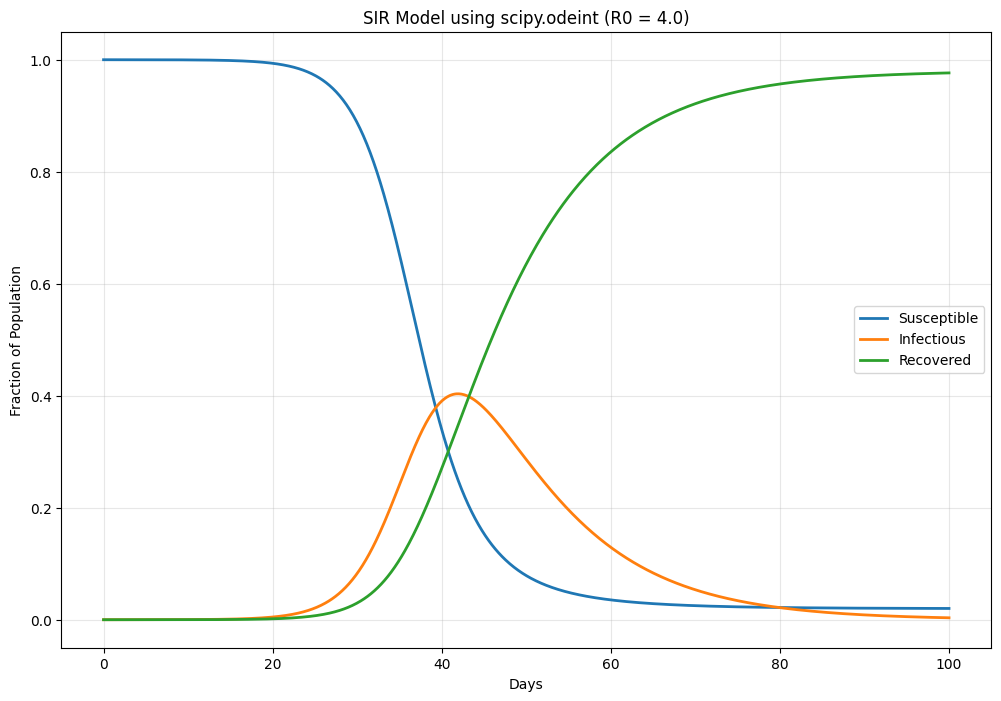

Peak infections: 3,363,298 people
Day of peak: 41.9 days


In [18]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt

def sir_model(y, t, beta, gamma, N_pop):
    """
    Define the SIR system for odeint
    y = [S, I, R] - current state
    t = current time (odeint passes this automatically)
    beta, gamma, N_pop = parameters
    """
    S, I, R = y

    dSdt = -beta * S * I / N_pop
    dIdt = beta * S * I / N_pop - gamma * I
    dRdt = gamma * I

    return [dSdt, dIdt, dRdt]

# Set up the problem (same as before)
gamma = 0.1  # 10-day infectious period
N_nyc = 8336817
initial_infected = 100
y0 = [N_nyc - initial_infected, initial_infected, 0]  # [S0, I0, R0]

# Time points where we want the solution
t = np.linspace(0, 100, 1000)  # 100 days, 1000 points

# Solve the ODE system
beta = 0.4  # Try different values
solution = odeint(sir_model, y0, t, args=(beta, gamma, N_nyc))

# Extract results
S_solution = solution[:, 0]
I_solution = solution[:, 1]
R_solution = solution[:, 2]

# Plot results
plt.figure(figsize=(12, 8))
plt.plot(t, S_solution/N_nyc, label='Susceptible', linewidth=2)
plt.plot(t, I_solution/N_nyc, label='Infectious', linewidth=2)
plt.plot(t, R_solution/N_nyc, label='Recovered', linewidth=2)
plt.xlabel('Days')
plt.ylabel('Fraction of Population')
plt.title(f'SIR Model using scipy.odeint (R0 = {beta/gamma:.1f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Peak infections: {max(I_solution):,.0f} people")
print(f"Day of peak: {t[np.argmax(I_solution)]:.1f} days")

Scipy's `odeint` automatically selects what scheme it will use, what size timestep to take, and makes sure the prediction is stable (no spiraling off to infinity!).

The code below gives you more parameters you can play with. By setting the accuracy you can control how expensive the solve is allowed to get.

In [19]:
from scipy.integrate import odeint

# Basic call with options
solution = odeint(sir_model, y0, t, args=(beta, gamma, N_nyc),
                  rtol=1e-8,      # Relative tolerance (default: 1.49e-8)
                  atol=1e-10,     # Absolute tolerance (default: 1.49e-12)
                  hmax=0.0,       # Maximum step size (0 = no limit)
                  hmin=0.0,       # Minimum step size
                  mxstep=0)       # Maximum number of steps (0 = 500*len(t))

# Get additional information
solution, info = odeint(sir_model, y0, t, args=(beta, gamma, N_nyc),
                        full_output=True)

print(f"Integration successful: {info['message']}")
print(f"Number of function evaluations: {info['nfe'][-1]}")

Integration successful: Integration successful.
Number of function evaluations: 333


# Submit today's work #
That's a wrap on ODEs. You now know enough to be dangerous, whether you use them to model engineering designs or any other dynamic system. Today's exercise will not be collected. Feel free to use time to focus on completing HW4, asking questions about the exam, or anything else you need to prepare for Wednesday's exam.